# ARTI404 – Image Processing | Lab 4
## Intensity Transformations and Filtering – Spatial Domain

**Name:** Abdulrahman Alshaikh  
**ID:** 2240004223

**Environment:** Google Colab / Jupyter Notebook

This notebook completes the procedural tasks and all three assessment tasks in the Lab 4 manual. Run the cells from top to bottom. Input images and processed images are saved in `Lab4/images/`.

## Install Required Libraries

In [1]:
import importlib.util
import subprocess
import sys

packages = {
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "cv2": "opencv-python-headless",
    "skimage": "scikit-image>=0.19",
    "PIL": "Pillow"
}
missing = [package for module, package in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Required libraries are ready.")

Required libraries are ready.


In [2]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data, exposure, img_as_float

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
image_dir = Path("Lab4/images")
image_dir.mkdir(parents=True, exist_ok=True)

## Prepare Lab Images

The assessment uses the original `moon`, `rocket`, and `chelsea` images from `skimage.data`.

The manual's thresholding example refers to `Parrot.png`, which was not supplied. The notebook checks common locations for that file; if it is absent, it uses the moon image as a clearly identified substitute for the thresholding demonstration. To use the manual's exact image, place `Parrot.png` beside the notebook or in an `images` folder and rerun the cells.

In [3]:
moon = data.moon()
rocket = data.rocket()
chelsea = data.chelsea()

for name, image in [("moon", moon), ("rocket", rocket), ("chelsea", chelsea)]:
    Image.fromarray(image).save(image_dir / f"{name}.png")
    print(f"{name}: shape={image.shape}, dtype={image.dtype}")

parrot_paths = [Path("Parrot.png"), Path("images/Parrot.png"), Path("../images/Parrot.png"), image_dir / "Parrot.png"]
parrot_path = next((path for path in parrot_paths if path.is_file()), None)

if parrot_path is not None:
    threshold_image = cv2.imread(str(parrot_path), cv2.IMREAD_GRAYSCALE)
    if threshold_image is None:
        raise ValueError(f"Cannot read {parrot_path}")
    threshold_source = "Parrot"
else:
    threshold_image = moon.copy()
    threshold_source = "Moon (Parrot.png was not supplied)"

Image.fromarray(threshold_image).save(image_dir / "threshold_input.png")
print(f"Thresholding source: {threshold_source}")

moon: shape=(512, 512), dtype=uint8
rocket: shape=(427, 640, 3), dtype=uint8
chelsea: shape=(300, 451, 3), dtype=uint8
Thresholding source: Moon (Parrot.png was not supplied)


## Part 1: Thresholding
### Task #1 — Apply fixed thresholds

Apply the manual's thresholds: **0, 50, 100, 150, and 200**. A pixel becomes 255 (white) when its intensity is greater than the threshold; otherwise, it becomes 0 (black).

Threshold   0:  99.91% white pixels
Threshold  50:  99.16% white pixels
Threshold 100:  93.93% white pixels
Threshold 150:   0.66% white pixels
Threshold 200:   0.16% white pixels


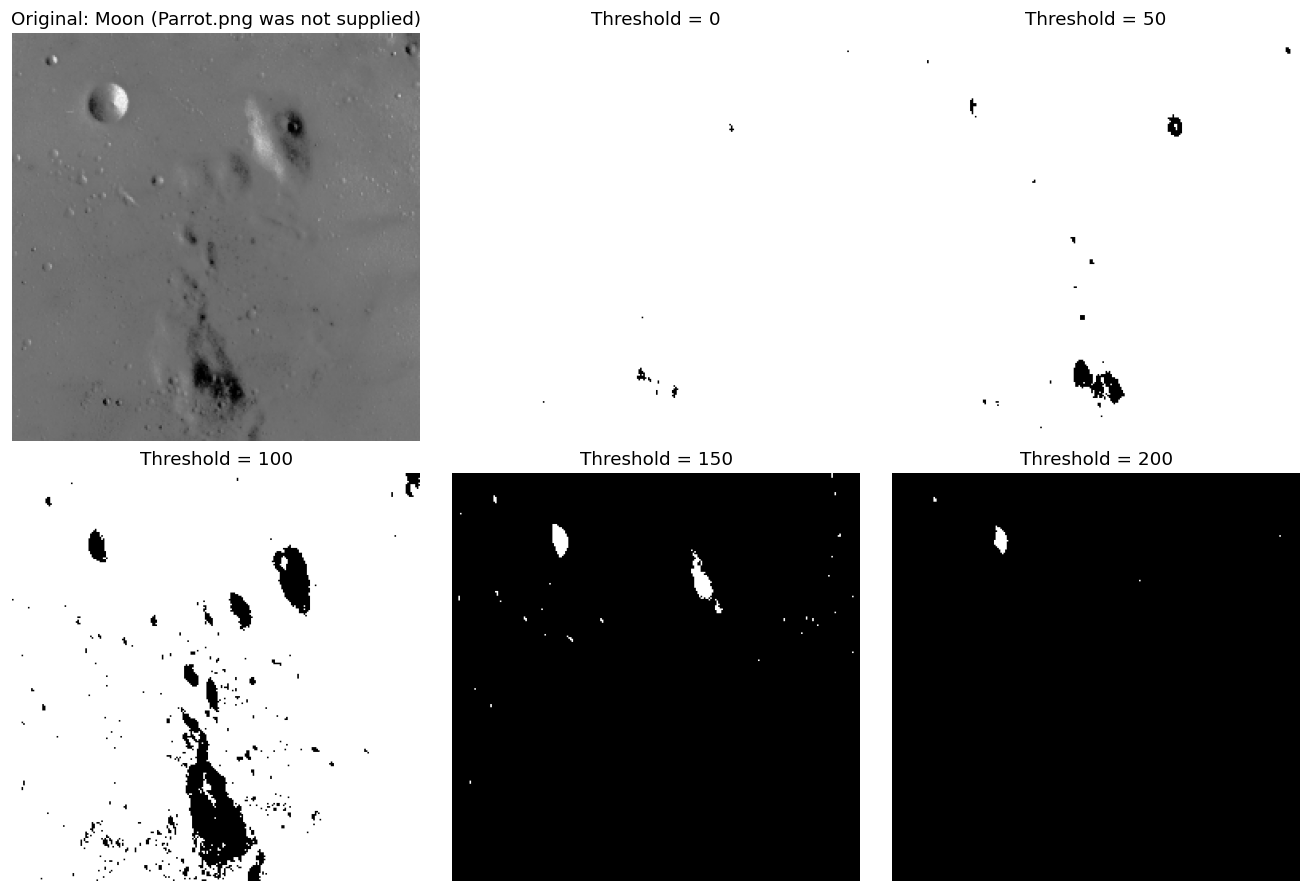

In [4]:
threshold_values = [0, 50, 100, 150, 200]
threshold_results = {}
fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()
axes[0].imshow(threshold_image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Original: {threshold_source}")
axes[0].axis("off")

for ax, threshold_value in zip(axes[1:], threshold_values):
    _, binary = cv2.threshold(threshold_image, threshold_value, 255, cv2.THRESH_BINARY)
    threshold_results[threshold_value] = binary
    ax.imshow(binary, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Threshold = {threshold_value}")
    ax.axis("off")
    Image.fromarray(binary).save(image_dir / f"threshold_{threshold_value}.png")
    print(f"Threshold {threshold_value:3}: {100 * np.mean(binary == 255):6.2f}% white pixels")

plt.show()

**Observation:** Increasing the threshold reduces the white foreground area. Only brighter pixels remain white at high thresholds.

## Part 2: Histogram Processing
### Task #2 — Contrast stretching using the 2nd and 98th percentiles

Load the moon image, find its 2nd and 98th percentile intensities, and stretch this interval to 0–255. Display each image with its histogram.

2nd percentile: 78.00
98th percentile: 129.00


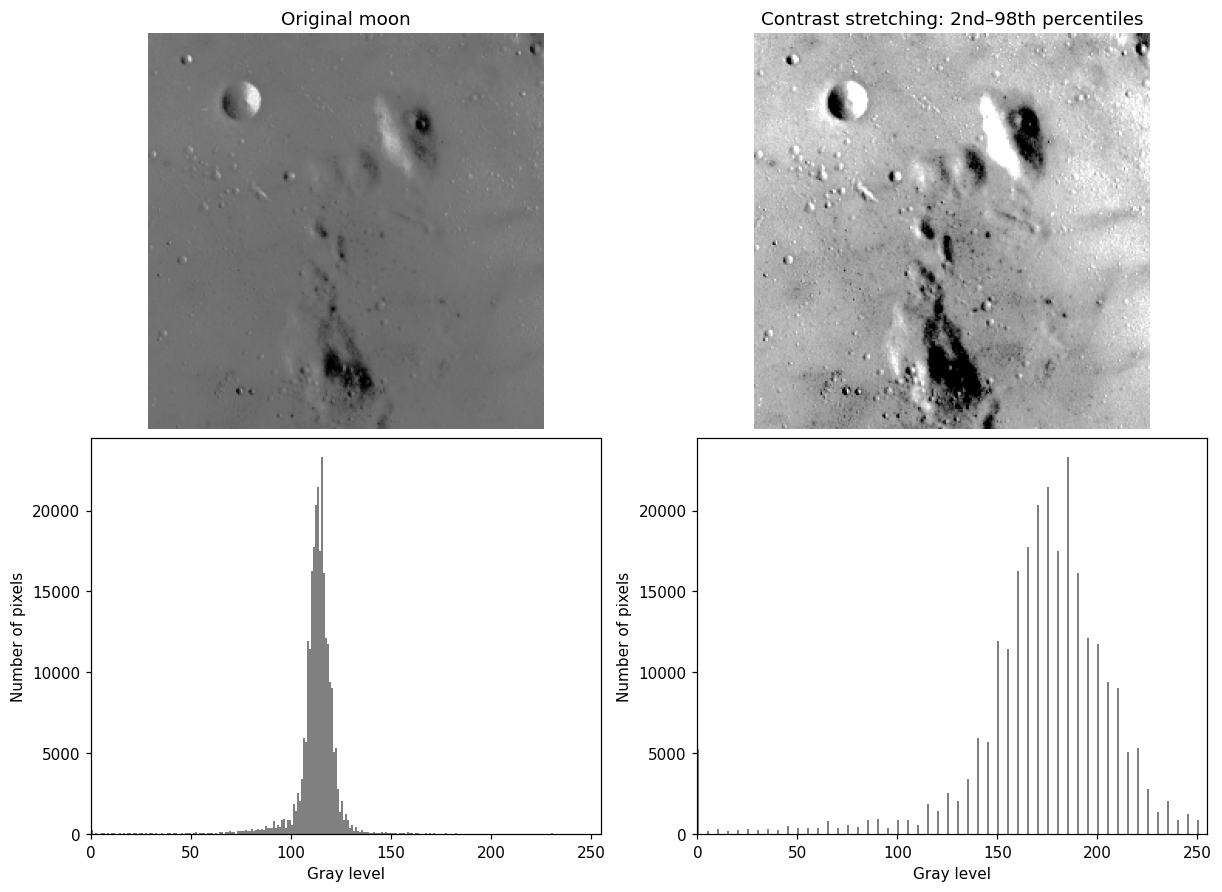

In [5]:
p2, p98 = np.percentile(moon, (2, 98))
moon_rescale_2_98 = exposure.rescale_intensity(moon, in_range=(p2, p98))
print(f"2nd percentile: {p2:.2f}")
print(f"98th percentile: {p98:.2f}")

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for column, (image, title) in enumerate([
    (moon, "Original moon"),
    (moon_rescale_2_98, "Contrast stretching: 2nd–98th percentiles")
]):
    axes[0, column].imshow(image, cmap="gray", vmin=0, vmax=255)
    axes[0, column].set_title(title)
    axes[0, column].axis("off")
    axes[1, column].hist(image.ravel(), bins=np.arange(257), color="gray")
    axes[1, column].set(xlabel="Gray level", ylabel="Number of pixels", xlim=(0, 255))

plt.show()
Image.fromarray(moon_rescale_2_98).save(image_dir / "moon_stretched_2_98.png")

**Observation:** Contrast stretching spreads the selected intensity interval over the full grayscale range. Values below the lower limit become black, and values above the upper limit become white.

## Assessment
### Task #1 — Contrast stretching using the 3rd and 80th percentiles

Use the original moon image and stretch the interval between its 3rd and 80th percentile intensities to 0–255. Display the result and its histogram.

3rd percentile: 87.00
80th percentile: 118.00
Output range: 0–255


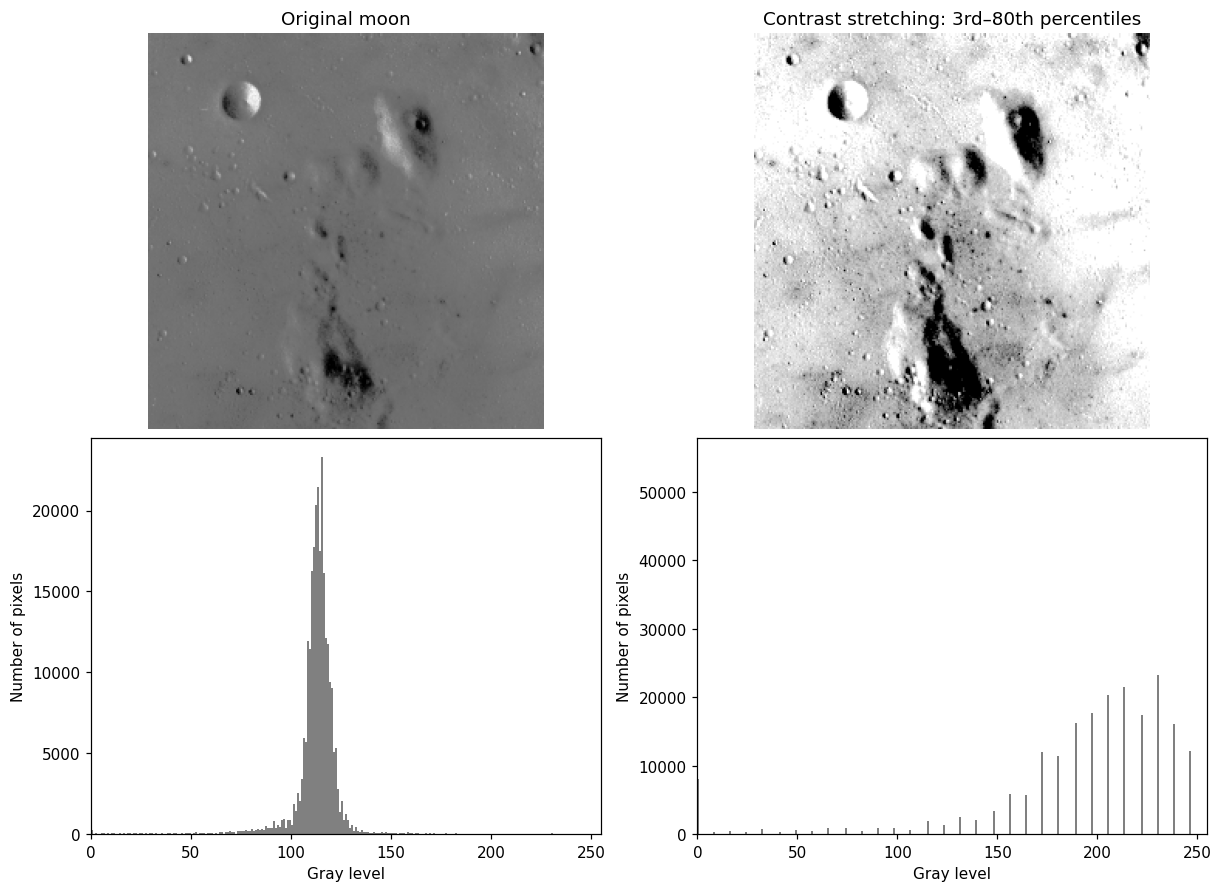

In [6]:
p3, p80 = np.percentile(moon, (3, 80))
moon_rescale_3_80 = exposure.rescale_intensity(moon, in_range=(p3, p80))
print(f"3rd percentile: {p3:.2f}")
print(f"80th percentile: {p80:.2f}")
print(f"Output range: {moon_rescale_3_80.min()}–{moon_rescale_3_80.max()}")

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for column, (image, title) in enumerate([
    (moon, "Original moon"),
    (moon_rescale_3_80, "Contrast stretching: 3rd–80th percentiles")
]):
    axes[0, column].imshow(image, cmap="gray", vmin=0, vmax=255)
    axes[0, column].set_title(title)
    axes[0, column].axis("off")
    axes[1, column].hist(image.ravel(), bins=np.arange(257), color="gray")
    axes[1, column].set(xlabel="Gray level", ylabel="Number of pixels", xlim=(0, 255))

plt.show()
Image.fromarray(moon_rescale_3_80).save(image_dir / "moon_stretched_3_80.png")

**Answer:** Intensities at or below the 3rd percentile map to black, and those at or above the 80th percentile map to white. Compared with the 2nd–98th percentile stretch, more bright pixels saturate, so some highlight detail is lost.

### Task #2 — Histogram equalization

Apply `exposure.equalize_hist` to the original moon image. The result is a floating-point image in the range 0–1, so its histogram uses that range.

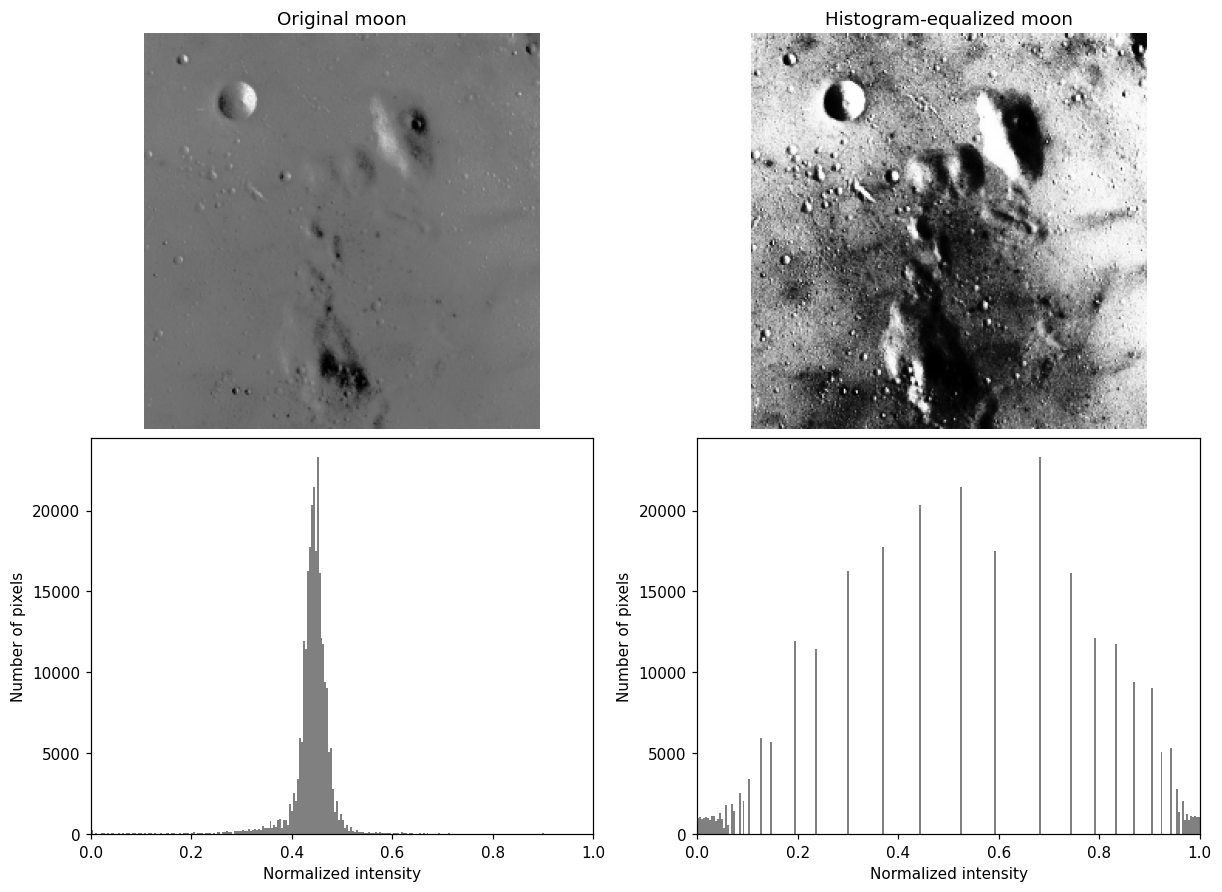

In [7]:
moon_equalized = exposure.equalize_hist(moon)
moon_float = img_as_float(moon)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for column, (image, title) in enumerate([
    (moon_float, "Original moon"),
    (moon_equalized, "Histogram-equalized moon")
]):
    axes[0, column].imshow(image, cmap="gray", vmin=0, vmax=1)
    axes[0, column].set_title(title)
    axes[0, column].axis("off")
    axes[1, column].hist(image.ravel(), bins=256, range=(0, 1), color="gray")
    axes[1, column].set(xlabel="Normalized intensity", ylabel="Number of pixels", xlim=(0, 1))

plt.show()
Image.fromarray(np.rint(moon_equalized * 255).astype(np.uint8)).save(image_dir / "moon_equalized.png")

**Answer:** Equalization redistributes intensities to improve contrast and reveal detail. The histogram is not perfectly flat because the original image has discrete intensity levels and many pixels share the same value. Its cumulative distribution becomes closer to a straight line.

### Task #3 — Histogram matching

Use **Chelsea as the source** and **rocket as the reference**. Match the red, green, and blue channels separately using `channel_axis=-1`.

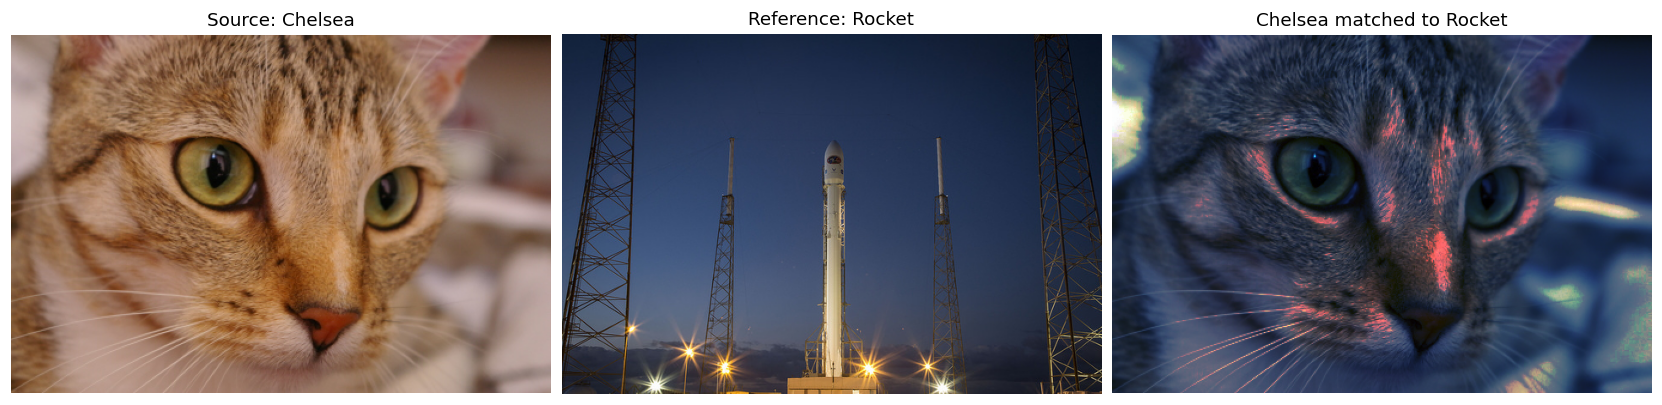

In [8]:
source = chelsea
reference = rocket
matched = exposure.match_histograms(source, reference, channel_axis=-1)
matched_display = np.clip(matched.astype(np.float64) / 255.0, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
for ax, image, title in zip(
    axes,
    [source, reference, matched_display],
    ["Source: Chelsea", "Reference: Rocket", "Chelsea matched to Rocket"]
):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

plt.show()
Image.fromarray(np.rint(matched_display * 255).astype(np.uint8)).save(image_dir / "chelsea_matched_to_rocket.png")

#### Compare the color histograms

Normalized frequencies allow comparison even though the source and reference images have different dimensions.

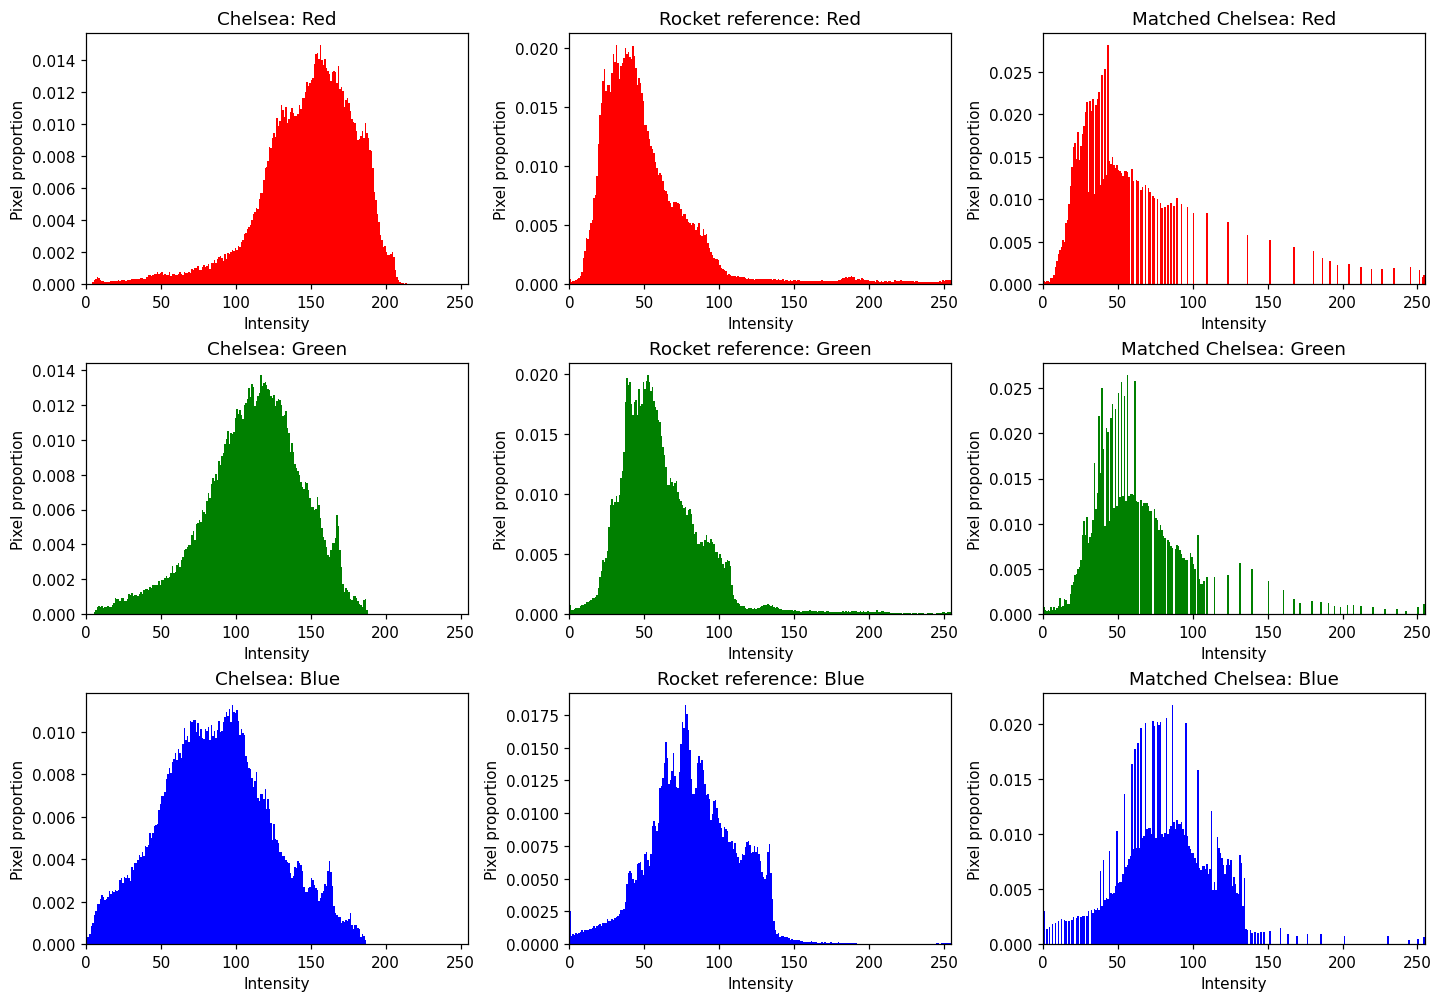

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9), constrained_layout=True)
images = [source, reference, matched]
titles = ["Chelsea", "Rocket reference", "Matched Chelsea"]

for channel, (color, label) in enumerate([("red", "Red"), ("green", "Green"), ("blue", "Blue")]):
    for column, (image, title) in enumerate(zip(images, titles)):
        values = image[..., channel].ravel()
        axes[channel, column].hist(
            values, bins=np.arange(257),
            weights=np.full(values.size, 1.0 / values.size), color=color
        )
        axes[channel, column].set(xlim=(0, 255), xlabel="Intensity", ylabel="Pixel proportion")
        axes[channel, column].set_title(f"{title}: {label}")

plt.show()

#### Compare cumulative distributions

The matched image's channel distributions should follow the rocket reference more closely.

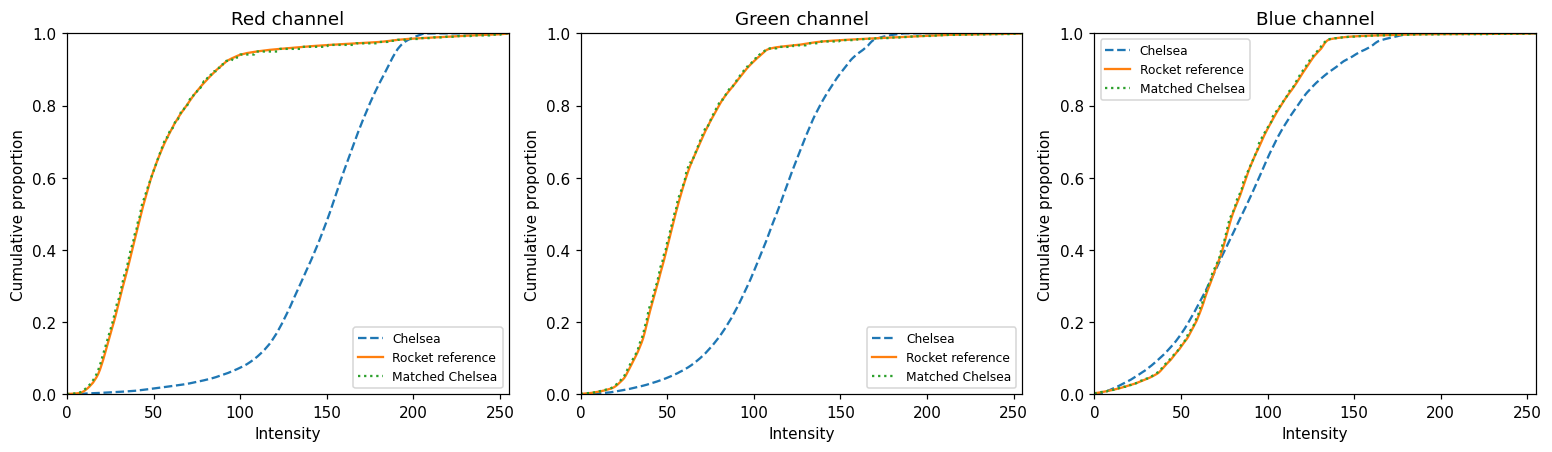

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for channel, (ax, label) in enumerate(zip(axes, ["Red", "Green", "Blue"])):
    for image, title, style in zip(images, titles, ["--", "-", ":"]):
        counts, edges = np.histogram(image[..., channel], bins=np.arange(257))
        cdf = np.cumsum(counts) / counts.sum()
        ax.plot(edges[:-1], cdf, linestyle=style, label=title)
    ax.set(title=f"{label} channel", xlabel="Intensity", ylabel="Cumulative proportion", xlim=(0, 255), ylim=(0, 1))
    ax.legend(fontsize=8)

plt.show()

**Answer:** Histogram matching changes Chelsea's color and intensity distributions to resemble the rocket image while preserving Chelsea's objects and spatial structure. The distributions are approximate because the images have different pixel counts and discrete intensity values.

## Files Created

Running this notebook saves the three original assessment images, the thresholding input, and processed results under `Lab4/images/`.

The manual also requests a PDF report and a GitHub submission link. This notebook is the requested `.ipynb` deliverable; it includes the code, figures, and brief observations for the report.

## References

- Provided **STUDENT PROCEDURAL MANUAL – Lab 4**.
- [scikit-image: Histogram equalization](https://scikit-image.org/docs/stable/auto_examples/color_exposure/plot_equalize.html).
- [scikit-image: Histogram matching](https://scikit-image.org/docs/0.24.x/auto_examples/color_exposure/plot_histogram_matching.html).